In [1]:
import os
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import os
import torch
import numpy as np
import pandas as pd
from natsort import natsorted
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import os
from torch.utils.data import random_split, DataLoader as TorchDataLoader
from torch.utils.data import Dataset
import torch

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from models import Simple1DCNN
import matplotlib.pyplot as plt
import argparse
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

featidx = list(range(0, 8))  # use all features
transform = StandardScaler()

## Loading all files

In [2]:
data_rock = {}
data_paper = {}
data_scissor = {}
data_none = {}

for sub in ['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07', 'subject08', 'subject09', 'subject10']:

    data_rock[sub] = []
    data_paper[sub] = []
    data_scissor[sub] = []
    data_none[sub] = []
    
    for ses in ['session01', 'session02', 'session03']:
        
        data        = np.load(rf'C:\0_Working\PhD\Papers\SP7_RoShamBo\roshambo-main\data\{sub}_{ses}_emg.npy', allow_pickle=True)
        annotation  = np.load(rf'C:\0_Working\PhD\Papers\SP7_RoShamBo\roshambo-main\data\{sub}_{ses}_ann.npy', allow_pickle=True)

        data = torch.tensor(data, dtype=torch.float32)
        data = transform.fit_transform(data)
        data = torch.tensor(data, dtype=torch.float32)

        for i in range(len(data)):
            if annotation[i] == b'rock' or annotation[i] == 'rock':
                data_rock[sub].append(data[i,:])
            elif annotation[i] == b'paper' or annotation[i] == 'paper':
                data_paper[sub].append(data[i,:])
            elif annotation[i] == b'scissor' or annotation[i] == 'scissor':
                data_scissor[sub].append(data[i,:])
            elif annotation[i] == b'none' or annotation[i] == 'none':
                data_none[sub].append(data[i,:])

Rock, Paper, Scissor, dNone = [], [], [], []
for sub in data_rock:
    Rock += data_rock[sub]

for sub in data_paper:
    Paper += data_paper[sub]

for sub in data_scissor:
    Scissor += data_scissor[sub]

for sub in data_none:    
    dNone += data_none[sub]

Rock = np.array(Rock)
Paper = np.array(Paper)
Scissor = np.array(Scissor)
dNone = np.array(dNone)

# setting abnormal data to the neighbouring data
def set_abnormal_data(data, threshold=5):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    for i in range(len(data)):
        if np.any(np.abs(data[i] - mean) > threshold * std):
            if i > 0:
                data[i] = data[i-1]
            else:
                data[i] = data[i+1]
    return data

Scissor_outlier_free = set_abnormal_data(Scissor.copy())
Rock_outlier_free = set_abnormal_data(Rock.copy())
Paper_outlier_free = set_abnormal_data(Paper.copy())
None_outlier_free = set_abnormal_data(dNone.copy())

min_time = min(Rock_outlier_free.shape[0], Paper_outlier_free.shape[0], Scissor_outlier_free.shape[0], None_outlier_free.shape[0])
Rock_final = Rock_outlier_free[:min_time]
Paper_final = Paper_outlier_free[:min_time]
Scissor_final = Scissor_outlier_free[:min_time]
None_final = None_outlier_free[:min_time]

In [3]:
print(f'Rock: {Rock_final.shape}, Paper: {Paper_final.shape}, Scissor: {Scissor_final.shape}, None: {None_final.shape}')

Rock: (59469, 8), Paper: (59469, 8), Scissor: (59469, 8), None: (59469, 8)


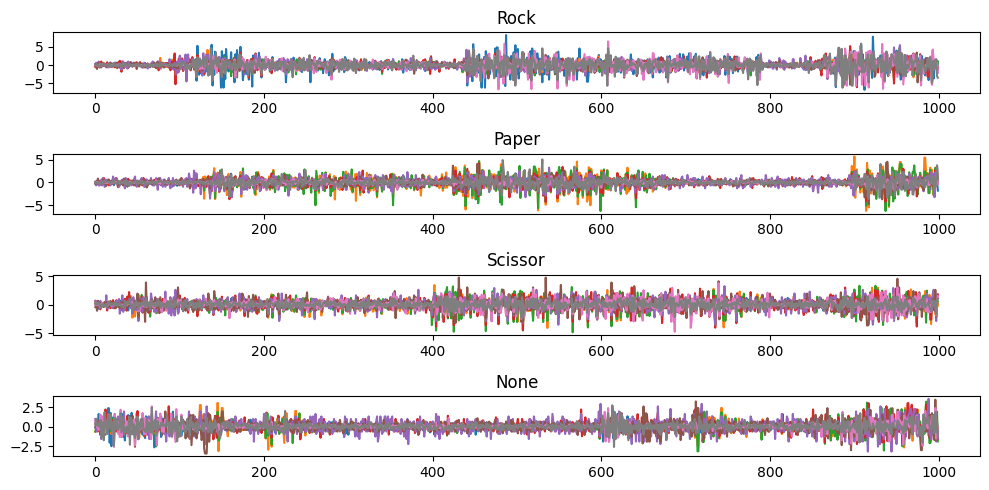

In [4]:
fig, axs = plt.subplots(4, 1, figsize=(10, 5))
axs[0].plot(Rock_final[:1000, featidx])
axs[0].set_title('Rock')
axs[1].plot(Paper_final[:1000, featidx])
axs[1].set_title('Paper')
axs[2].plot(Scissor_final[:1000, featidx])
axs[2].set_title('Scissor')
axs[3].plot(None_final[:1000, featidx])
axs[3].set_title('None')
plt.tight_layout()
plt.show()

### Reference Ratio Calculation 

In [5]:
# median of each class
Rock_normalized = np.zeros_like(Rock_final)
Paper_normalized = np.zeros_like(Paper_final)
Scissor_normalized = np.zeros_like(Scissor_final)
None_normalized = np.zeros_like(None_final)

for i in range(Rock_final.shape[1]):
    Rock_normalized[:, i] = Rock_final[:, i] / np.median(Rock_final[:, i])
    Paper_normalized[:, i] = Paper_final[:, i] / np.median(Paper_final[:, i])
    Scissor_normalized[:, i] = Scissor_final[:, i] / np.median(Scissor_final[:, i])
    None_normalized[:, i] = None_final[:, i] / np.median(None_final[:, i])

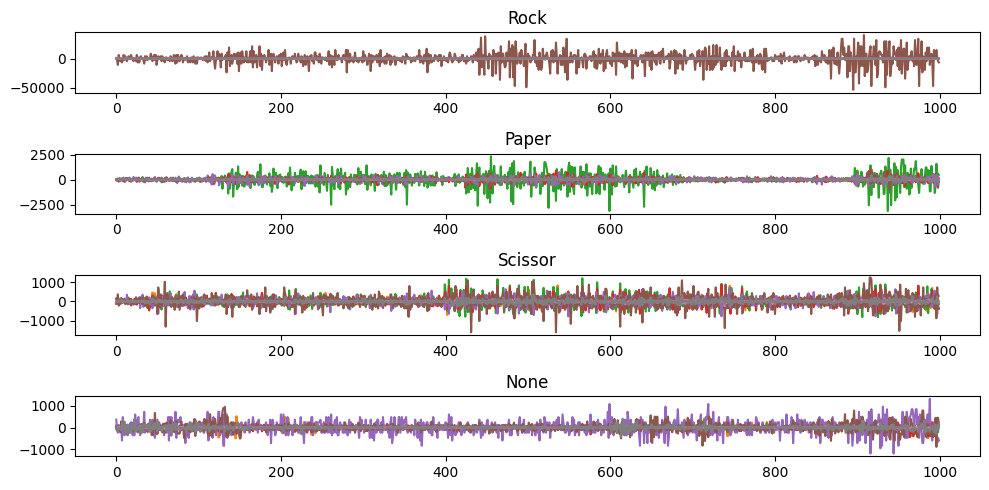

In [6]:
fig, axs = plt.subplots(4, 1, figsize=(10, 5))
axs[0].plot(Rock_normalized[:1000, featidx])
axs[0].set_title('Rock')
axs[1].plot(Paper_normalized[:1000, featidx])
axs[1].set_title('Paper')
axs[2].plot(Scissor_normalized[:1000, featidx])
axs[2].set_title('Scissor')
axs[3].plot(None_normalized[:1000, featidx])
axs[3].set_title('None')
plt.tight_layout()
plt.show()

### Visualizing the distributions

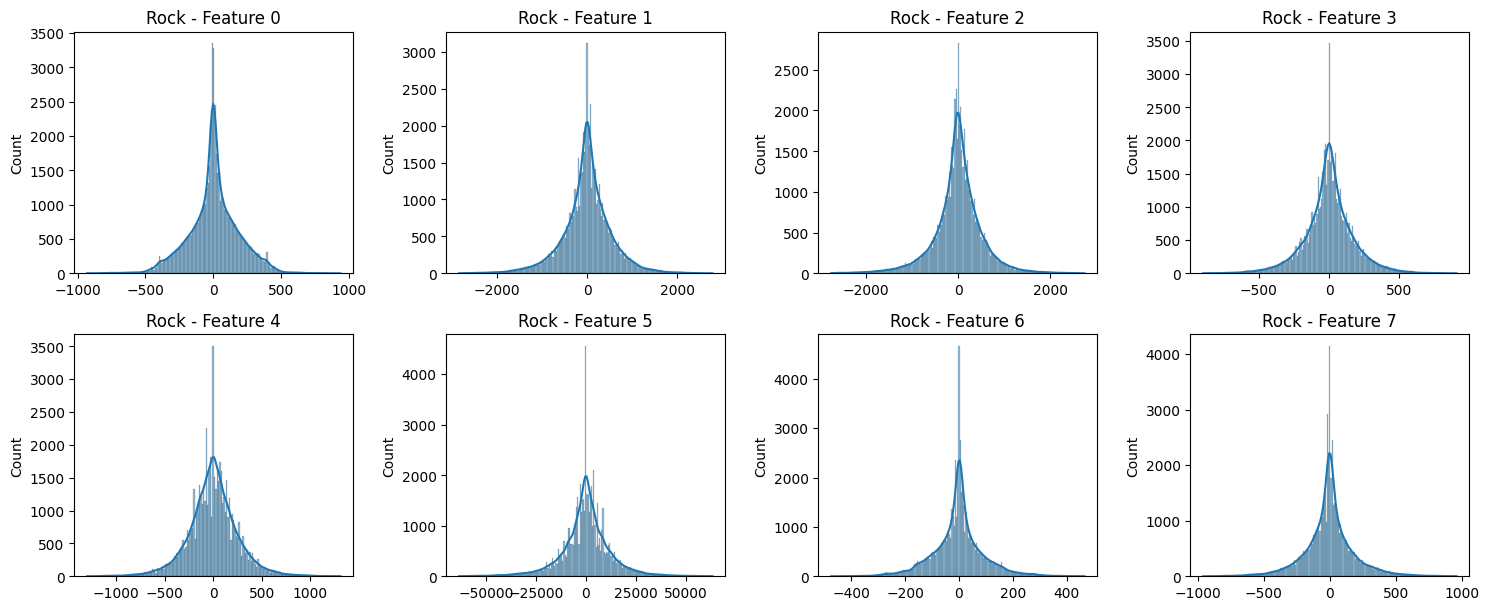

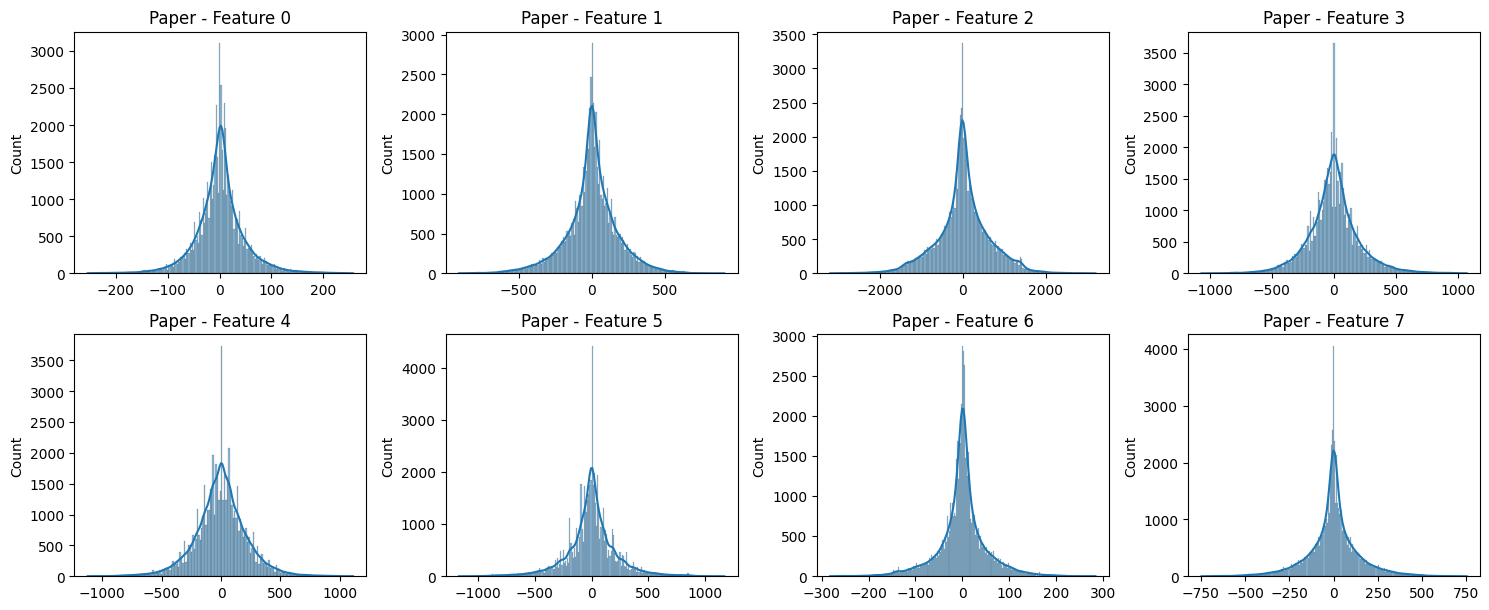

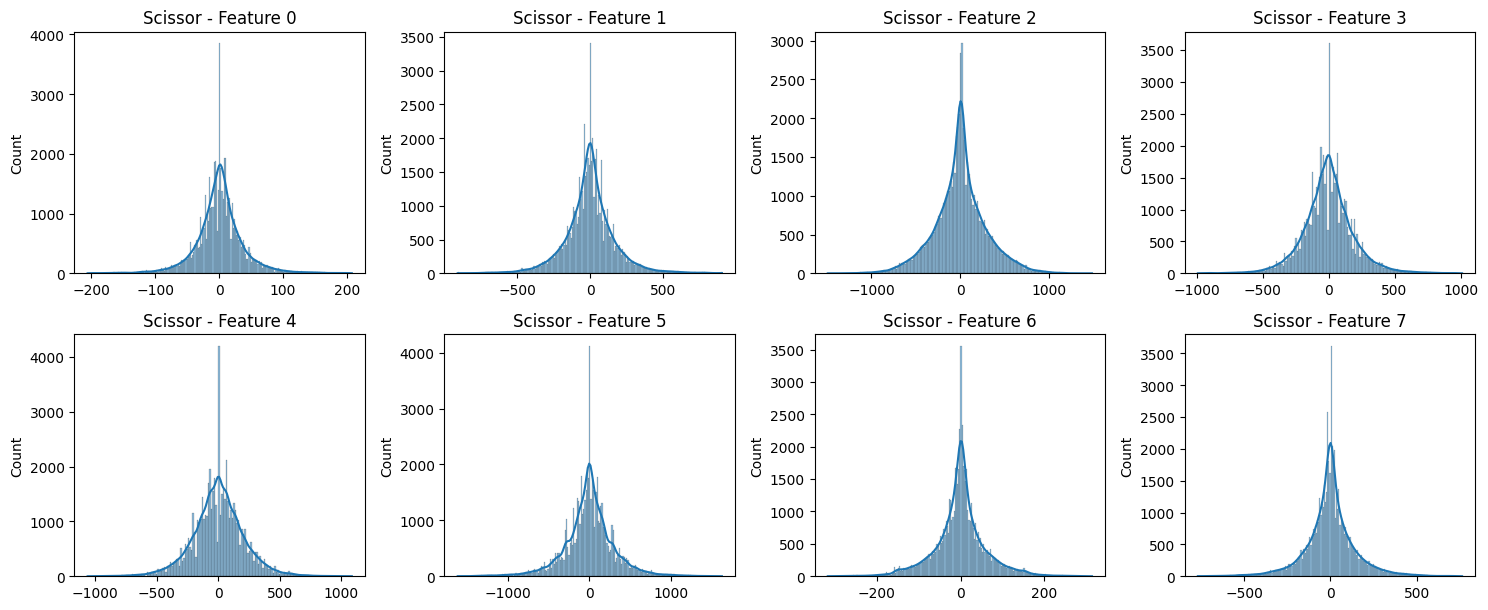

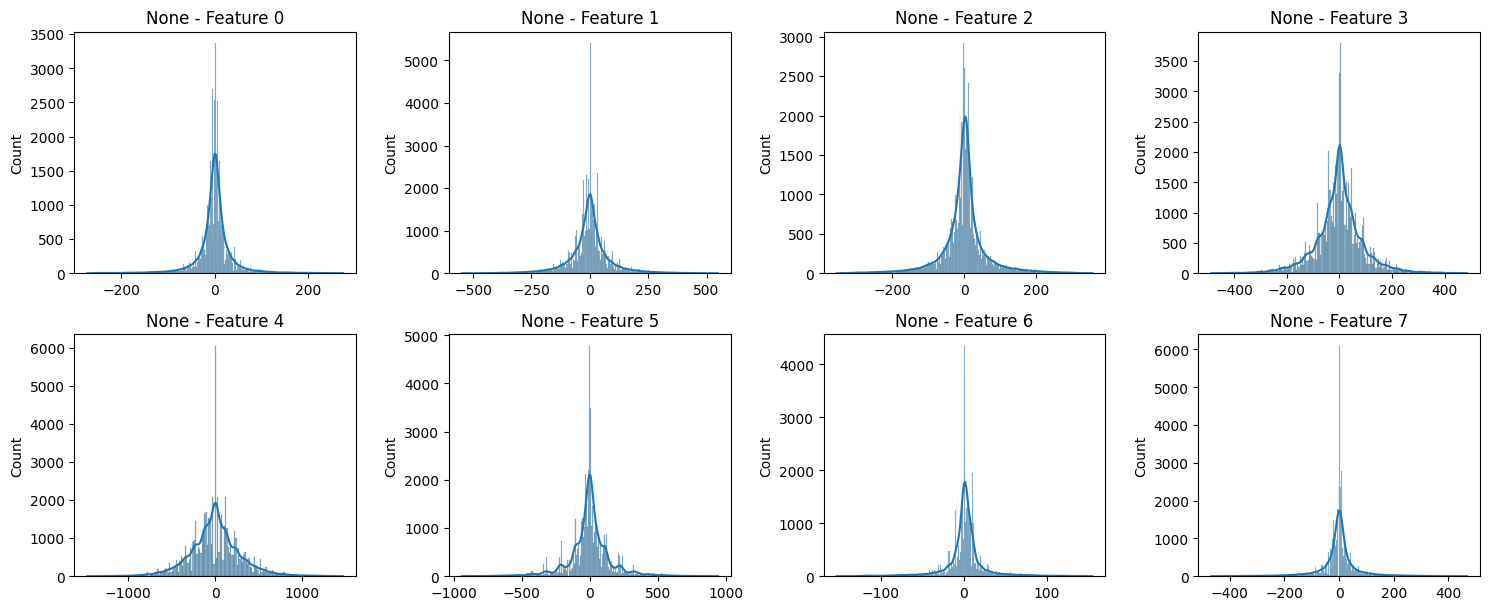

In [22]:
# visualizing the assumed guassian distributions using the normalized data
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_distributions(data, class_name):
    num_features = data.shape[1]
    plt.figure(figsize=(15, 3 * (num_features // 4 + 1)))
    for i in range(num_features):
        plt.subplot((num_features // 4 + 1), 4, i + 1)
        sns.histplot(data[:, i], kde=True)
        plt.title(f'{class_name} - Feature {i}')
    plt.tight_layout()
    plt.show()

plot_feature_distributions(Rock_normalized, "Rock")
plot_feature_distributions(Paper_normalized, "Paper")
plot_feature_distributions(Scissor_normalized, "Scissor")
plot_feature_distributions(None_normalized, "None")


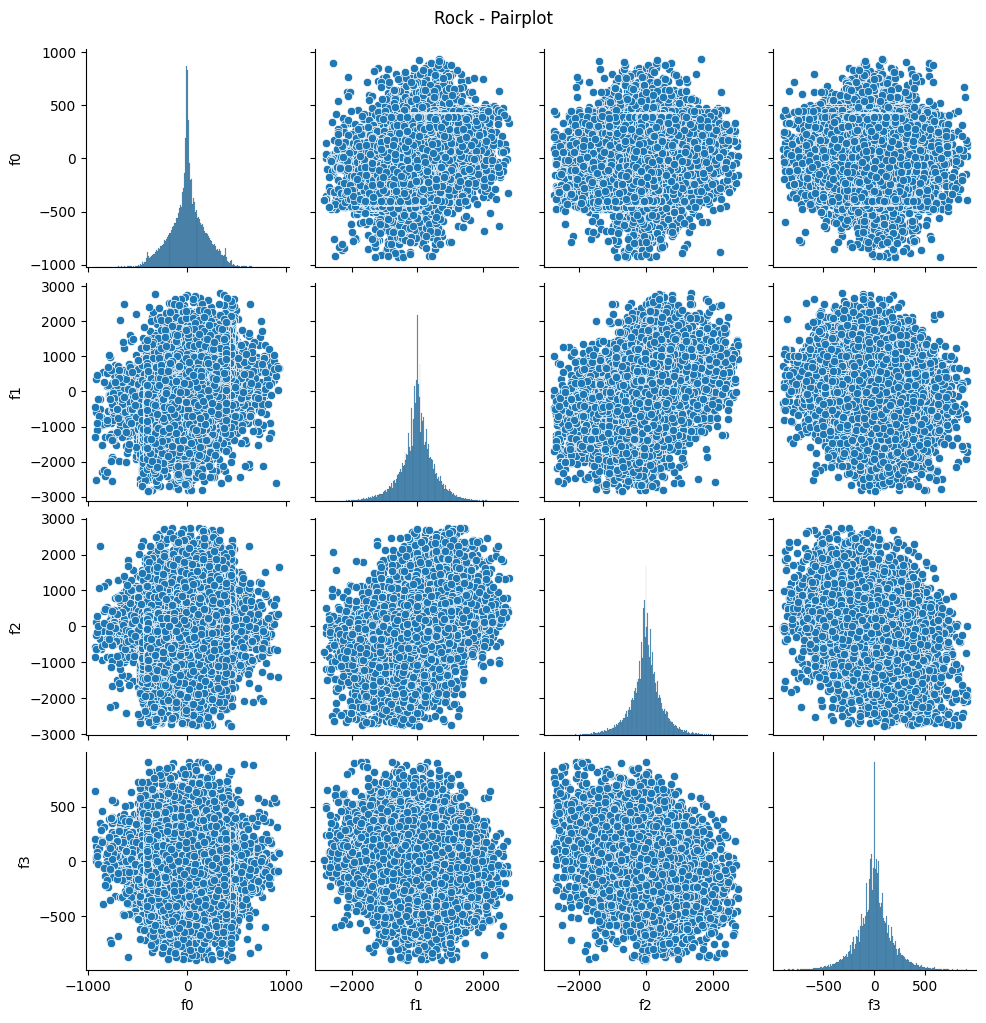

In [23]:
import pandas as pd

# Select a few features for visualizing pairwise relations
subset = Rock_normalized[:, :4]  # Choose first 4 features
df = pd.DataFrame(subset, columns=[f"f{i}" for i in range(subset.shape[1])])
sns.pairplot(df)
plt.suptitle("Rock - Pairplot", y=1.02)
plt.show()


In [ ]:
from scipy.stats import shapiro, normaltest

def test_univariate_normality(data, class_name):
    print(f"Normality test results for {class_name}:")
    for i in range(data.shape[1]):
        stat, p = normaltest(data[:, i])  # or use shapiro(data[:, i])
        print(f"Feature {i}: p = {p:.4f} {'(Gaussian)' if p > 0.05 else '(Not Gaussian)'}")
        
test_univariate_normality(Rock_normalized, "Rock")

import pingouin as pg
df = pd.DataFrame(Rock_normalized)
mv_test = pg.multivariate_normality(df, alpha=0.05)
print("Rock Multivariate Normality:", mv_test)

Normality test results for Rock:
Feature 0: p = 0.0000 (Not Gaussian)
Feature 1: p = 0.0000 (Not Gaussian)
Feature 2: p = 0.0000 (Not Gaussian)
Feature 3: p = 0.0000 (Not Gaussian)
Feature 4: p = 0.0000 (Not Gaussian)
Feature 5: p = 0.0000 (Not Gaussian)
Feature 6: p = 0.0000 (Not Gaussian)
Feature 7: p = 0.0000 (Not Gaussian)


In [9]:
import pingouin as pg
df = pd.DataFrame(Rock_normalized[:5000, :])  
mv_test = pg.multivariate_normality(df, alpha=0.05)
print("Rock Multivariate Normality:", mv_test)

df = pd.DataFrame(Scissor_normalized[:5000, :])
mv_test = pg.multivariate_normality(df, alpha=0.05)
print("Scissor Multivariate Normality:", mv_test)

df = pd.DataFrame(Paper_normalized[:5000, :])
mv_test = pg.multivariate_normality(df, alpha=0.05) 
print("Paper Multivariate Normality:", mv_test)

Rock Multivariate Normality: HZResults(hz=20.87634363344536, pval=0.0, normal=False)
Scissor Multivariate Normality: HZResults(hz=5.319845856152, pval=0.0, normal=False)
Paper Multivariate Normality: HZResults(hz=15.05812238847538, pval=0.0, normal=False)


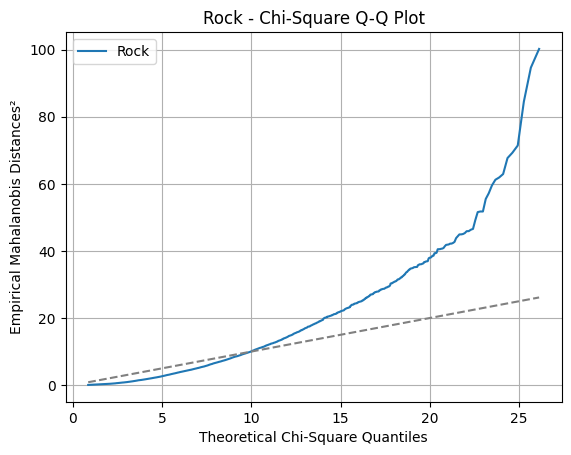

In [11]:
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

def plot_mahalanobis(data, class_name):
    cov = np.cov(data, rowvar=False)
    mean = np.mean(data, axis=0)
    inv_cov = np.linalg.inv(cov)
    d = [mahalanobis(row, mean, inv_cov) for row in data]
    chi2_vals = chi2.ppf(np.linspace(0.001, 0.999, len(d)), df=data.shape[1])
    d_sorted = np.sort(np.square(d))
    
    plt.plot(chi2_vals, d_sorted, label=f'{class_name}')
    plt.plot(chi2_vals, chi2_vals, '--', color='gray')
    plt.xlabel("Theoretical Chi-Square Quantiles")
    plt.ylabel("Empirical Mahalanobis Distances²")
    plt.title(f"{class_name} - Chi-Square Q-Q Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_mahalanobis(Rock_normalized[:5000,:], "Rock")

### Estimate Multivariate Distributions  

In [7]:
# define a function to calculate mean and covariance
def calculate_mean_covariance(data):
    mean = np.mean(data, axis=0)
    covariance = np.cov(data, rowvar=False)
    return mean, covariance


# Estimate Multivariate Distributions
mean_r, cov_r = calculate_mean_covariance(Rock_normalized)
mean_p, cov_p = calculate_mean_covariance(Paper_normalized)
mean_s, cov_s = calculate_mean_covariance(Scissor_normalized)
mean_n, cov_n = calculate_mean_covariance(None_normalized)

### Compute Multivariate KLD

In [9]:
# define a function to calculate KLD using mean and covariance
def calculate_kld(mean1, cov1, mean2, cov2):
    diff = mean1 - mean2
    kld = 0.5 * (np.trace(np.linalg.inv(cov2) @ cov1) + diff.T @ np.linalg.inv(cov2) @ diff - len(mean1) + np.log(np.linalg.det(cov2) / np.linalg.det(cov1)))
    return kld

In [10]:
KLD_m_rp = calculate_kld(mean_r, cov_r, mean_p, cov_p)
KLD_m_rs = calculate_kld(mean_r, cov_r, mean_s, cov_s)
KLD_m_ps = calculate_kld(mean_p, cov_p, mean_s, cov_s)

print(f"Multivariate KLD Rock-Paper: {KLD_m_rp}")
print(f"Multivariate KLD Rock-Scissor: {KLD_m_rs}")
print(f"Multivariate KLD Paper-Scissor: {KLD_m_ps}")  

Multivariate KLD Rock-Paper: 2134.148629288729
Multivariate KLD Rock-Scissor: 1230.4082755001928
Multivariate KLD Paper-Scissor: 3.17146046876156


In [11]:
# Jenson-Shannon Divergence

JSD_rp = 0.5 * (calculate_kld(mean_r, cov_r, mean_p, cov_p) + calculate_kld(mean_p, cov_p, mean_r, cov_r))
JSD_rs = 0.5 * (calculate_kld(mean_r, cov_r, mean_s, cov_s) + calculate_kld(mean_s, cov_s, mean_r, cov_r))
JSD_ps = 0.5 * (calculate_kld(mean_p, cov_p, mean_s, cov_s) + calculate_kld(mean_s, cov_s, mean_p, cov_p))

print(f"Jenson-Shannon Divergence Rock-Paper: {JSD_rp}")
print(f"Jenson-Shannon Divergence Rock-Scissor: {JSD_rs}")
print(f"Jenson-Shannon Divergence Paper-Scissor: {JSD_ps}")

Jenson-Shannon Divergence Rock-Paper: 1069.9259089194168
Jenson-Shannon Divergence Rock-Scissor: 618.1856935923605
Jenson-Shannon Divergence Paper-Scissor: 2.2487021529132245


In [13]:
from scipy.spatial.distance import cdist

def energy_distance(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    nx = len(x)
    ny = len(y)
    
    d_xx = np.sum(cdist(x, x)) / (nx * nx)
    d_yy = np.sum(cdist(y, y)) / (ny * ny)
    d_xy = np.sum(cdist(x, y)) / (nx * ny)
    
    return 2 * d_xy - d_xx - d_yy

ed = energy_distance(Rock_normalized[:1000,:], Paper_normalized[:1000,:])
print(f"Energy Distance (Rock vs Paper): {ed:.4f}")
ed = energy_distance(Rock_normalized[:1000,:], Scissor_normalized[:1000,:])
print(f"Energy Distance (Rock vs Scissor): {ed:.4f}")
ed = energy_distance(Paper_normalized[:1000,:], Scissor_normalized[:1000,:])
print(f"Energy Distance (Paper vs Scissor): {ed:.4f}")

Energy Distance (Rock vs Paper): 3312.2081
Energy Distance (Rock vs Scissor): 3395.5481
Energy Distance (Paper vs Scissor): 34.6542


## Statistical Test

### Bootstrap Resampling

In [17]:
def bootstrap_kld(data1, data2, data3, n_iter=1000, seed=42):
    np.random.seed(seed)
    delta_klds = []

    n1, n2, n3 = len(data1), len(data2), len(data3)

    for _ in range(n_iter):
        # Resample with replacement
        sample1 = data1[np.random.choice(n1, n1, replace=True)]
        sample2 = data2[np.random.choice(n2, n2, replace=True)]
        sample3 = data3[np.random.choice(n3, n3, replace=True)]

        # Calculate mean and covariance
        m1, c1 = calculate_mean_covariance(sample1)
        m2, c2 = calculate_mean_covariance(sample2)
        m3, c3 = calculate_mean_covariance(sample3)

        # Calculate KLDs
        kld_12 = calculate_kld(m1, c1, m2, c2)  # e.g., Rock ‖ Paper
        kld_23 = calculate_kld(m2, c2, m3, c3)  # e.g., Paper ‖ Scissor

        delta_kld = kld_23 - kld_12
        delta_klds.append(delta_kld)

    return np.array(delta_klds)


In [20]:
delta_klds = bootstrap_kld(Scissor_normalized, Paper_normalized, Rock_normalized)

# Compute 95% confidence interval
ci_low = np.percentile(delta_klds, 2.5)
ci_high = np.percentile(delta_klds, 97.5)
mean_delta = np.mean(delta_klds)

print(f"Mean ΔKLD = {mean_delta:.4f}")
print(f"95% CI = ({ci_low:.4f}, {ci_high:.4f})")

# Hypothesis test
if ci_low > 0:
    print("✅ Reject H0: Scissor vs Paper is significantly more overlapping than Paper vs Rock.")
else:
    print("❌ Fail to reject H0: No significant difference found.")


Mean ΔKLD = 4.3766
95% CI = (4.3455, 4.4083)
✅ Reject H0: Scissor vs Paper is significantly more overlapping than Paper vs Rock.


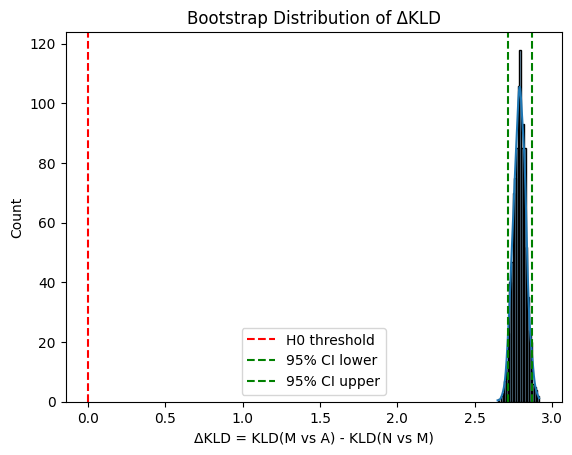

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(delta_klds, kde=True)
plt.axvline(x=0, color='red', linestyle='--', label='H0 threshold')
plt.axvline(ci_low, color='green', linestyle='--', label='95% CI lower')
plt.axvline(ci_high, color='green', linestyle='--', label='95% CI upper')
plt.title("Bootstrap Distribution of ΔKLD")
plt.xlabel("ΔKLD = KLD(M vs A) - KLD(N vs M)")
plt.legend()
plt.show()
